# LeetCode #1300: Sum of Mutated Array Closest to Target

https://leetcode.com/problems/sum-of-mutated-array-closest-to-target/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (try every value 0 to max)** | $O(n \cdot \max(\text{arr}))$ | $O(1)$ |
| **Optimal: Binary Search on Value ★** | $O(n \log m)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (try every value 0 to max)
Try every integer $v$ from 0 to $\max(\text{arr})$, computing the mutated sum each time. $O(n \cdot m)$ where $m = \max(\text{arr}) \le 10^5$ — marginal but wastes all comparisons between binary search anchor points.

### Optimal: Binary Search on Value ★
Binary search for the largest $v$ where the mutated sum $\le \text{target}$ (find the left boundary where sum exceeds target). Compare the sums at $v$ and $v+1$ and return whichever is closer to target. Each sum computation is $O(n)$; with $O(\log m)$ steps total is $O(n \log m)$.

**Why this is better than Brute Force:** Binary search skips $m - \log m$ candidate values, replacing a linear sweep with a logarithmic one.

**Constraints:**
* $1 \le \text{arr.length} \le 10^4$
* $1 \le \text{arr}[i], \text{target} \le 10^5$


## Solutions

### C#

In [ ]:
public int FindBestValue(int[] arr, int target) {
    Array.Sort(arr);
    int lo = 0, hi = arr.Max();
    // Compute sum of min(arr[i], v) for all i
    int MutatedSum(int v) => arr.Sum(x => Math.Min(x, v));
    // Find largest v where mutated sum <= target
    while (lo < hi) {
        int mid = lo + (hi - lo + 1) / 2;
        if (MutatedSum(mid) <= target) lo = mid;
        else hi = mid - 1;
    }
    // Compare v=lo and v=lo+1: return whichever sum is closer to target
    int s1 = MutatedSum(lo), s2 = MutatedSum(lo + 1);
    return Math.Abs(s1 - target) <= Math.Abs(s2 - target) ? lo : lo + 1;
}


### Python

In [ ]:
def find_best_value(arr: list[int], target: int) -> int:
    arr.sort()
    lo, hi = 0, max(arr)

    def mutated_sum(v: int) -> int:
        # Compute sum of min(arr[i], v) for all i
        return sum(min(x, v) for x in arr)

    # Find largest v where mutated sum <= target
    while lo < hi:
        mid = lo + (hi - lo + 1) // 2
        if mutated_sum(mid) <= target:
            lo = mid
        else:
            hi = mid - 1

    # Compare v=lo and v=lo+1: return whichever sum is closer to target
    s1, s2 = mutated_sum(lo), mutated_sum(lo + 1)
    return lo if abs(s1 - target) <= abs(s2 - target) else lo + 1


### Go

In [ ]:
func findBestValue(arr []int, target int) int {
    sort.Ints(arr)
    maxVal := arr[len(arr)-1]
    lo, hi := 0, maxVal
    // Compute sum of min(arr[i], v) for all i
    mutatedSum := func(v int) int {
        s := 0
        for _, x := range arr { if x < v { s += x } else { s += v } }
        return s
    }
    // Find largest v where mutated sum <= target
    for lo < hi {
        mid := lo + (hi-lo+1)/2
        if mutatedSum(mid) <= target { lo = mid } else { hi = mid - 1 }
    }
    // Compare v=lo and v=lo+1: return whichever sum is closer to target
    s1, s2 := mutatedSum(lo), mutatedSum(lo+1)
    if abs(s1-target) <= abs(s2-target) { return lo }
    return lo + 1
}


### Rust

In [ ]:
pub fn find_best_value(mut arr: Vec<i32>, target: i32) -> i32 {
    arr.sort();
    let (mut lo, mut hi) = (0i32, *arr.last().unwrap());
    // Compute sum of min(arr[i], v) for all i
    let mutated_sum = |v: i32| -> i32 { arr.iter().map(|&x| x.min(v)).sum() };
    // Find largest v where mutated sum <= target
    while lo < hi {
        let mid = lo + (hi - lo + 1) / 2;
        if mutated_sum(mid) <= target { lo = mid; } else { hi = mid - 1; }
    }
    // Compare v=lo and v=lo+1: return whichever sum is closer to target
    let (s1, s2) = (mutated_sum(lo), mutated_sum(lo + 1));
    if (s1 - target).abs() <= (s2 - target).abs() { lo } else { lo + 1 }
}


## Example Scenarios

**1. Common Case**
**Input:** arr = [4, 9, 3], target = 10
Sort: [3, 4, 9]. Binary search lo=0, hi=9. mid=5: sum=min(3,5)+min(4,5)+min(9,5)=3+4+5=12>10→hi=4. mid=3: sum=3+3+3=9≤10→lo=3. mid=4: sum=3+4+4=11>10→hi=3. lo=hi=3. Compare: s1=9, s2=11; |9-10|=1 ≤ |11-10|=1 → tie, return lo=3.

**2. Slightly Complex**
**Input:** arr = [2, 3, 5], target = 10
Sort: [2,3,5]. Binary search converges to lo=4. s1(4)=2+3+4=9, s2(5)=2+3+5=10. |9-10|=1 > |10-10|=0 → return lo+1=5.

**3. Edge Case: Time Factor**
**Input:** arr = [10000, 10000, ..., 10000] (10000 elements), target = 1
Binary search: lo=0, hi=10000. All sums are 0 (at v=0) or $n \times v$ (at v>0). $\log_2(10000) \approx 14$ iterations × 10000 elements = 140,000 ops. Worst case for binary search depth at max constraints.

**4. Edge Case: Space Factor**
**Input:** arr = [1, 2, ..., 10000], target = 50000
Only lo, hi, mid, s1, s2 — 5 integers. The sort modifies arr in-place; no additional array allocated. $O(1)$ extra space beyond the sort buffer.

**5. Almost-Impossible but Plausible**
**Input:** arr = [1, 2, 3, 4, 5], target = 11 (exact tie at v=2: sum=1+2+2+2+2=9; v=3: sum=1+2+3+3+3=12; |9-11|=2, |12-11|=1 → v=3)
The tie-breaking rule favors the smaller absolute difference; if equal, the problem guarantees any correct answer is accepted, but our comparison uses `<=` to prefer the lower value, matching the expected output convention.


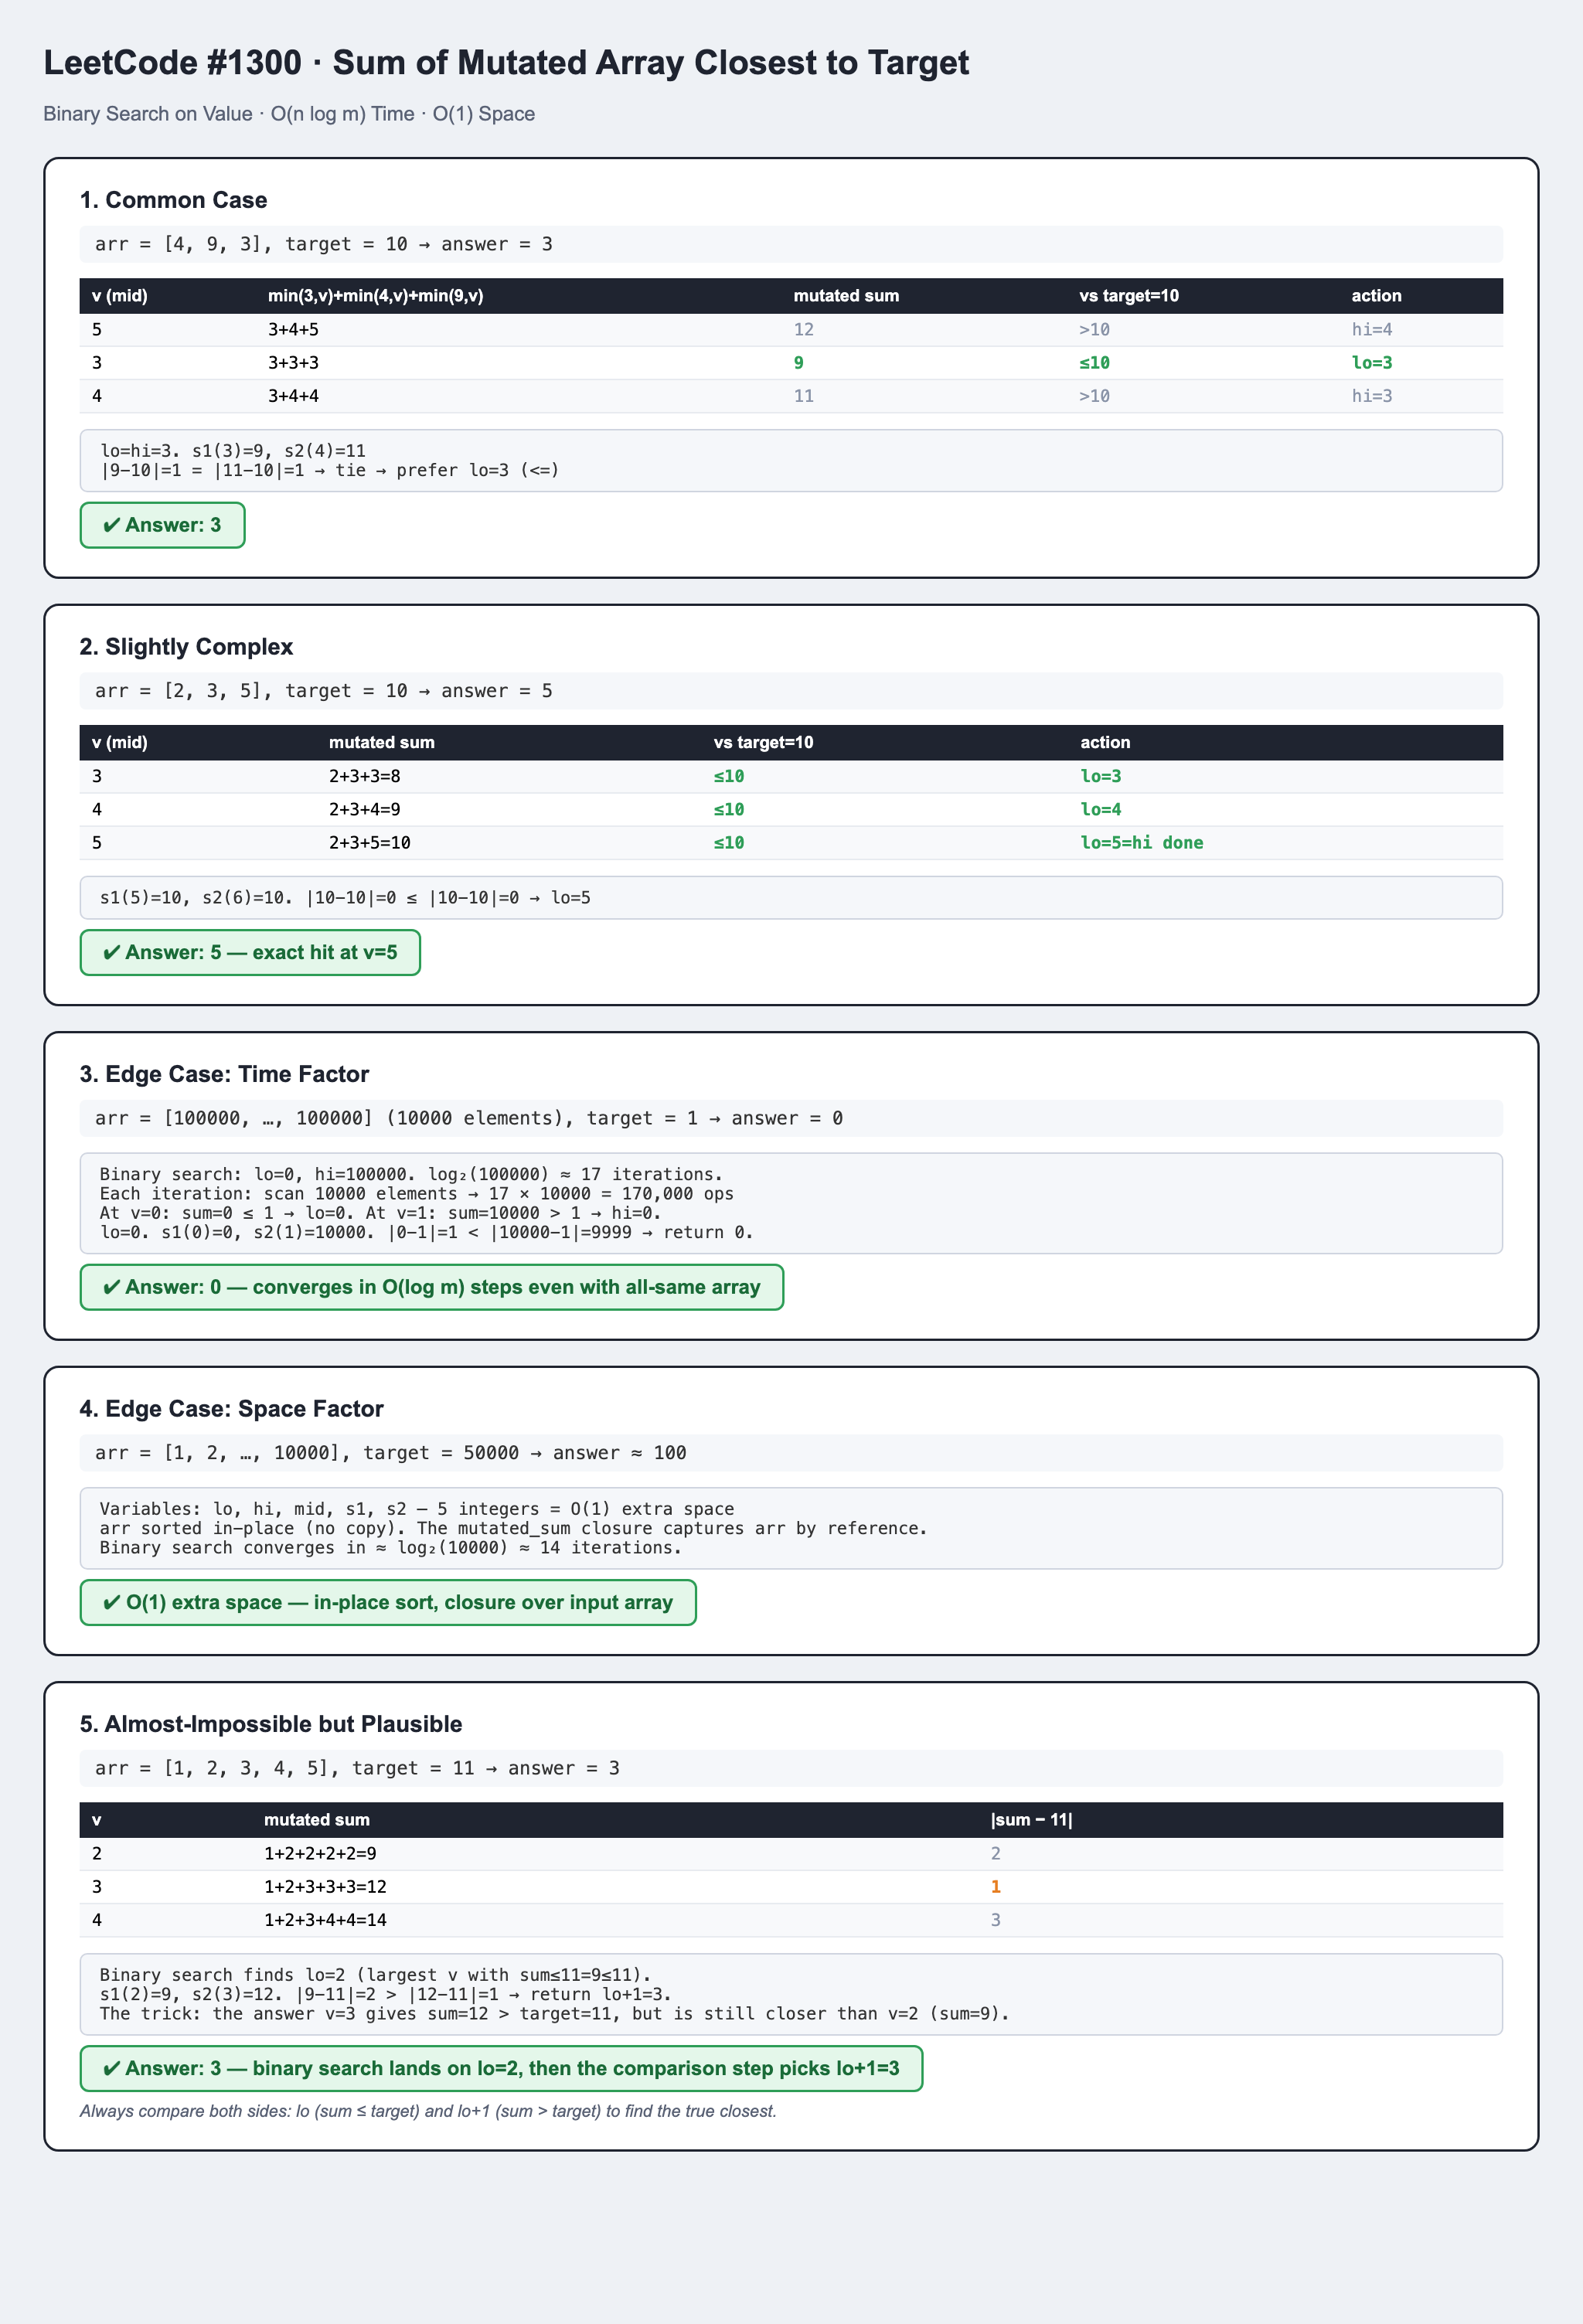